# **Valeur RGB (mean , std)**

-Permet de ramener toutes les valeurs des pixels [0,255] dans une petite plage (généralement autour de[0,1]), ce qui aide le modèle à converger rapidement

-les gens utilisent les valeurs par défaut du dataset "ImageNet" (des photos de chiens, voitures, etc.). Comme mon Dataset contient de la peau et de l'acné, le canal Rouge sera naturellement beaucoup plus élevé que le Bleu. Calculer mes propres moyennes rendra mon modèle surement bien plus performant.



In [29]:
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# préparation et recherche des images
def calculer_statistiques(dossier_path):
    dossier = Path(dossier_path)
    extensions = {'.jpg', '.jpeg', '.png'}
    
    # On récupère tous les chemins valides
    images_paths = [p for p in dossier.rglob("*") if p.suffix.lower() in extensions]
    
    print(f"📊 Début du calcul sur {len(images_paths)} images...")
    
    pixel_count = 0
    sum_pixels = np.zeros(3)
    sum_sq_pixels = np.zeros(3)
    
    for p in tqdm(images_paths, desc="Analyse des pixels"):
        try:
            # Ouvre, convertit en RGB, transforme en tableau numpy et met à l'échelle [0, 1]
            img = np.array(Image.open(p).convert("RGB")).astype(np.float32) / 255.0
            
            # Nombre total de pixels dans cette image (Largeur x Hauteur)
            pixels_dans_image = img.shape[0] * img.shape[1]
            pixel_count += pixels_dans_image
            
            # Somme des pixels par canal de couleur (Rouge, Vert, Bleu)
            sum_pixels += img.sum(axis=(0, 1))
            sum_sq_pixels += (img ** 2).sum(axis=(0, 1))
            
        except Exception as e:
            print(f"Erreur sur {p.name}: {e}")
            
    # Calcul final mathématique
    mean = sum_pixels / pixel_count
    variance = (sum_sq_pixels / pixel_count) - (mean ** 2)
    std = np.sqrt(variance)
    
    return mean, std

# --- EXÉCUTION ---
# Ton chemin exact vers le dossier contenant les 629 images formatées
MON_DOSSIER = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne\dataset"

moyenne, ecart_type = calculer_statistiques(MON_DOSSIER)

print("\n" + "="*50)
print("✅ RÉSULTATS DE NORMALISATION POUR TON MODÈLE")
print("="*50)
print(f"Moyenne (Mean) [Rouge, Vert, Bleu] : {np.round(moyenne, 4).tolist()}")
print(f"Écart-type (Std) [Rouge, Vert, Bleu] : {np.round(ecart_type, 4).tolist()}")
print("="*50)

📊 Début du calcul sur 1363 images...


Analyse des pixels:   0%|          | 0/1363 [00:00<?, ?it/s]

Analyse des pixels: 100%|██████████| 1363/1363 [00:13<00:00, 101.63it/s]


✅ RÉSULTATS DE NORMALISATION POUR TON MODÈLE
Moyenne (Mean) [Rouge, Vert, Bleu] : [0.4996, 0.4011, 0.3593]
Écart-type (Std) [Rouge, Vert, Bleu] : [0.3475, 0.3008, 0.2851]


# **Pipeline**

-Commencont par separer physiquement non image dans un dossier **train** et **val** avec un ratio (80 , 20) pour garantir que mon model ne triche pas

-Nous allons recuperer notre dataset et le transfomer Pytorch dataset

-Nous allons faire un peu d'augmentation sur le sens d'orientation des images , le contrast et la luminosité des images

-Normalisé nos image avec les **mean** et **std** de nos valeur RGB

In [30]:
import random
import shutil
from pathlib import Path
from tqdm import tqdm

def split_dataset(source_dir, dest_dir, train_ratio=0.8):
    source_path = Path(source_dir)
    dest_path = Path(dest_dir)
    
    # On fixe le "seed" aléatoire pour que le mélange soit toujours le même 
    # si tu relances le script (très important pour la reproductibilité)
    random.seed(42)
    
    # On liste tous les dossiers de classes (Acne, Blackhead, etc.)
    # On ignore le dossier "rejected_outliers" s'il est là
    classes = [d for d in source_path.iterdir() if d.is_dir() and d.name != "rejected_outliers"]
    
    print(f"📁 Création de la structure dans {dest_path.name}...")
    
    extensions = {'.jpg', '.jpeg', '.png'}
    
    for cls in classes:
        # 1. Lister toutes les images de cette classe
        images = [p for p in cls.rglob("*") if p.suffix.lower() in extensions]
        
        # 2. Mélanger au hasard
        random.shuffle(images)
        
        # 3. Calculer où couper la liste (ex: 80% de 100 images = index 80)
        split_index = int(len(images) * train_ratio)
        
        train_images = images[:split_index]
        val_images = images[split_index:]
        
        # 4. Créer les dossiers de destination (ex: split_data/train/Acne)
        train_cls_dir = dest_path / "train" / cls.name
        val_cls_dir = dest_path / "val" / cls.name
        
        train_cls_dir.mkdir(parents=True, exist_ok=True)
        val_cls_dir.mkdir(parents=True, exist_ok=True)
        
        # 5. Copier les fichiers
        for img in tqdm(train_images, desc=f"Copie Train - {cls.name}"):
            shutil.copy(img, train_cls_dir / img.name)
            
        for img in tqdm(val_images, desc=f"Copie Val   - {cls.name}"):
            shutil.copy(img, val_cls_dir / img.name)
            
    print("\n✅ Dataset divisé avec succès !")
    print(f"Dossier Train : {dest_path / 'train'}")
    print(f"Dossier Val   : {dest_path / 'val'}")

# --- EXÉCUTION ---
DOSSIER_SOURCE = MON_DOSSIER
DOSSIER_FINAL  = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne"

# On met 80% des images dans train, et 20% dans val
split_dataset(DOSSIER_SOURCE, DOSSIER_FINAL, train_ratio=0.8)

📁 Création de la structure dans acne...


Copie Val   - normal: 100%|██████████| 149/149 [00:00<00:00, 1090.22it/s]


✅ Dataset divisé avec succès !
Dossier Train : C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne\train
Dossier Val   : C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne\val


In [31]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image



# Define a custom PyTorch Dataset
class SkinDataset(Dataset):
    # a. L'initialisation (Ce qui se passe quand on crée le dataset)
    def __init__(self, image_dir, transform=None):
        # 1. On définit les extensions acceptées
        extensions_valides = {'.jpg', '.jpeg', '.png'}
        # 2. On cherche tous les fichiers et on ne garde que ceux avec la bonne extension
        self.paths = [
            p for p in Path(image_dir).rglob("*") 
            if p.suffix.lower() in extensions_valides
        ]
        self.transform = transform
    # b. La taille (Combien d'images j'ai au total ?)
    def __len__(self):
        return len(self.paths)
    
    #  Le récupérateur (Comment je donne UNE image au modèle quand il la demande ?)
    #  On ouvre l'image à l'index demandé (idx) et on s'assure qu'elle est en couleurs (RGB)
    def __getitem__(self, idx):
        # 1. Le chemin du fichier
        img_path = self.paths[idx]
        
        # 2. L'image
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
            
        # 3. Le Label (La solution)
        nom_dossier = img_path.parent.name.lower()
        
        # ⚠️ Vérifie bien que les noms ici correspondent EXACTEMENT 
        # aux noms de tes dossiers (majuscules/minuscules)
        classes = {"acne_resized": 0, "normal": 1} 
        label = classes[nom_dossier]
        
        # On renvoie les DEUX éléments !
        return img, label
    
# Pour l'entraînement (Train) : On veut créer de la diversité (Data Augmentation)
# retourner l'image,modifier aléatoirement la luminosité et le contraste, et la normalisation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Modifie aléatoirement la luminosité et le contraste de +/- 20%
    transforms.ToTensor(),
    transforms.Normalize(moyenne, ecart_type),
])
# Pour la validation (Val / Test) : AUCUNE triche, on ne modifie pas l'image !
val_transform = transforms.Compose([   # pas d'augmentation ici !
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(moyenne, ecart_type),
])

# 1. Le Dataset et DataLoader pour l'ENTRAÎNEMENT (Train)
train_set = SkinDataset(
    image_dir=r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne\train", 
    transform=train_transform # Avec ColorJitter, RandomFlip, etc.
)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)

# 2. Le Dataset et DataLoader pour la VALIDATION (Val)
val_set = SkinDataset(
    image_dir=r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne\val", 
    transform=val_transform # SANS ColorJitter, SANS Flip ! Juste la normalisation.
)
# Note : pas besoin de "shuffle=True" pour la validation, l'ordre n'a pas d'importance pour l'examen
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Détection de la carte graphique (très important pour que ce soit rapide)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"L'entraînement se fera sur : {device}")

# 2.On charge le modèle avec les poids les plus récents (ImageNet)
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# 3.On bloque les couches de bases pour ne pas les modifier lors des premières étapes d'entraînement
for param in model.parameters():
    param.requires_grad = False

# 4. On adapte la sortie pour NOS 2 classes (Acné vs Normal)
num_classes = 2
# La structure de MobileNetV2.classifier[1] est la couche Linear de sortie
# En faisant ça, on récupère donc le nombre de neurones d'entrée de la dernière couche (1280)
in_features = model.classifier[1].in_features
# On remplace la couche de sortie par une nouvelle couche Linear (2 classes : Acne, Normal)
model.classifier[1] = nn.Linear(in_features, num_classes)

# 5. On envoie le modèle sur la bonne puce (CPU ou Carte Graphique)
model = model.to(device)

print("✅ Modèle MobileNetV2 prêt pour 2 classes (Acné, Normal).")

L'entraînement se fera sur : cpu
✅ Modèle MobileNetV2 prêt pour 2 classes (Acné, Normal).


# **Configuration du Loss et Optimizer**

-Le professeur : criterion car son but est corriger la copie , te mettre des penalité quand la réponse n'est pas bonne

-le mécanicien: En connaisance la penalité du professeur , il sait d'ou vient le probleme et va essaié de corriger cette erreur

In [33]:
# Le Professeur : Calcule l'erreur pour de la classification
criterion = nn.CrossEntropyLoss()

# Le Mécanicien : Modifie UNIQUEMENT les poids de la nouvelle couche (classifier)
# lr=0.001 est une bonne vitesse d'apprentissage pour commencer
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# **Configuration Entrainement**

In [34]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Active le Dropout (éteindre aléatoirement certains neurones) et la Batch Normalization
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Nettoyage des gradients précédents

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass (Calcul de l'erreur + mise à jour des poids)
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

# **Configuration de l'Evaluation**

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


def evaluate_epoch(model, dataloader, criterion, device):
    """
    Évaluation légère utilisée à chaque epoch.
    Retourne uniquement (loss, accuracy, f1) sans aucun affichage.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1


def evaluate_full(model, dataloader, criterion, device, dataset_name="Validation"):
    """
    Évaluation complète post-entraînement.
    Affiche : métriques globales, rapport par classe, matrice de confusion.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    # Métriques globales
    print(f"\n{'='*50}")
    print(f"  ÉVALUATION FINALE — {dataset_name.upper()}")
    print(f"{'='*50}")
    print(f"  Loss     : {avg_loss:.4f}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  F1 (weighted) : {f1:.4f}")
    print(f"{'='*50}\n")

    # Rapport détaillé par classe
    print("Rapport détaillé par classe :")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, colorbar=False)
    plt.title(f'Matrice de Confusion — {dataset_name}')
    plt.tight_layout()
    plt.show()

    return avg_loss, accuracy, f1

Lancement de l'entraînement sur cpu...
Epoch  1/5 | Train — Loss: 0.4829  Acc: 0.7817  F1: 0.9432 | Val   — Loss: 0.2514  Acc: 0.9744  F1: 0.9744
Epoch  2/5 | Train — Loss: 0.2758  Acc: 0.9174  F1: 0.9341 | Val   — Loss: 0.1652  Acc: 0.9670  F1: 0.9671
Epoch  3/5 | Train — Loss: 0.2030  Acc: 0.9385  F1: 0.9469 | Val   — Loss: 0.1324  Acc: 0.9780  F1: 0.9781
Epoch  4/5 | Train — Loss: 0.1937  Acc: 0.9367  F1: 0.9432 | Val   — Loss: 0.1168  Acc: 0.9707  F1: 0.9707
Epoch  5/5 | Train — Loss: 0.1641  Acc: 0.9450  F1: 0.9625 | Val   — Loss: 0.0973  Acc: 0.9817  F1: 0.9817

Entraînement terminé en 15m 26s
Meilleure Accuracy en Validation : 0.9817

  ÉVALUATION FINALE — TRAIN
  Loss     : 0.1372
  Accuracy : 0.9596
  F1 (weighted) : 0.9597

Rapport détaillé par classe :
              precision    recall  f1-score   support

        Acne       0.93      0.99      0.96       495
      Normal       0.99      0.94      0.96       595

    accuracy                           0.96      1090
   macro

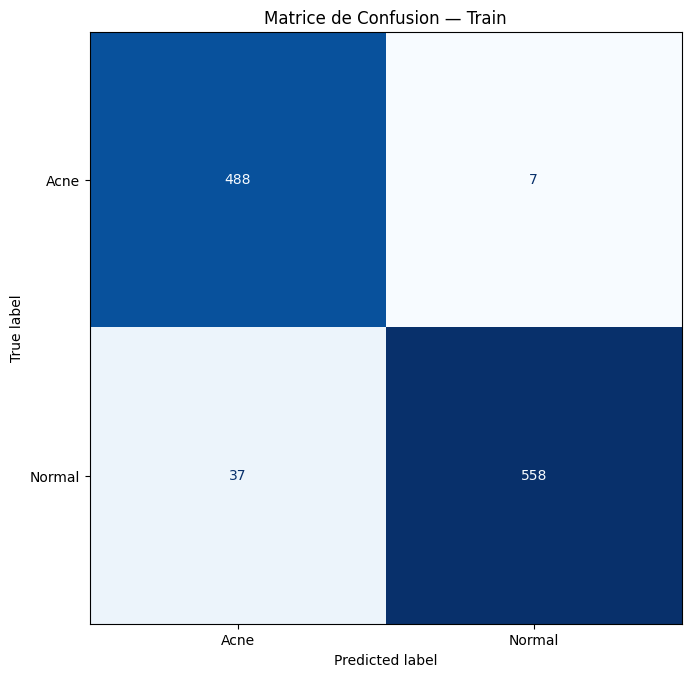


  ÉVALUATION FINALE — VALIDATION
  Loss     : 0.0973
  Accuracy : 0.9817
  F1 (weighted) : 0.9817

Rapport détaillé par classe :
              precision    recall  f1-score   support

        Acne       0.96      1.00      0.98       124
      Normal       1.00      0.97      0.98       149

    accuracy                           0.98       273
   macro avg       0.98      0.98      0.98       273
weighted avg       0.98      0.98      0.98       273



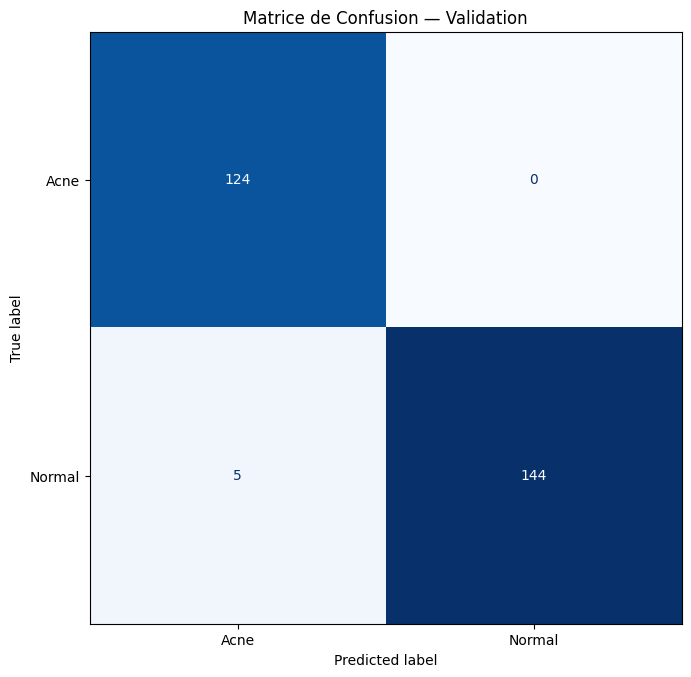

(0.09734687015359655, np.float64(0.9816849816849816), 0.9817096886395001)

In [36]:
import time
import copy

# ── Configuration de l'expérience ────────────────────────────────────────────
num_epochs     = 5
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc   = 0.0

# Historique : loss, accuracy et F1 pour train ET val
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   []
}

print(f"Lancement de l'entraînement sur {device}...")
since = time.time()

# ── Boucle principale ────────────────────────────────────────────────────────
for epoch in range(num_epochs):

    # Phase TRAIN
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Phase EVAL train (légère — pas de plots)
    _, _, train_f1 = evaluate_epoch(
        model, train_loader, criterion, device
    )

    # Phase EVAL validation (légère — pas de plots)
    val_loss, val_acc, val_f1 = evaluate_epoch(
        model, val_loader, criterion, device
    )

    # Stockage dans l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(float(train_acc))
    history['train_f1'].append(float(train_f1))
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Sauvegarde du meilleur modèle (val accuracy)
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:>2}/{num_epochs} | "
        f"Train — Loss: {train_loss:.4f}  Acc: {float(train_acc):.4f}  F1: {train_f1:.4f} | "
        f"Val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}"
    )

# ── Bilan de l'entraînement ──────────────────────────────────────────────────
time_elapsed = time.time() - since
print(f'\nEntraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Meilleure Accuracy en Validation : {best_val_acc:.4f}')

# ── Chargement des meilleurs poids ────────────────────────────────────────────
model.load_state_dict(best_model_wts)

# ── Évaluation finale complète : TRAIN puis VALIDATION ───────────────────────
# On définit le nom exact de nos 2 classes dans l'ordre (0 puis 1)
class_names = ["Acne", "Normal"]
# Maintenant on peut lancer l'évaluation sereinement !
evaluate_full(model, train_loader, criterion, device, "Train")
evaluate_full(model, val_loader,   criterion, device, "Validation")

 # **Enregistrement du models Fin tune**

In [38]:
import torch
import os
from datetime import datetime

# Paramètres de sauvegarde
# Chemin absolu du notebook en cours
NOTEBOOK_DIR = os.path.abspath("") 

# Remonter 2 niveaux (training/ -> notebooks/ -> vision/) puis /models
MODEL_DIR  = os.path.normpath(os.path.join(NOTEBOOK_DIR, "..", "..", "models"))
MODEL_NAME = "mobilenetv2_baseline_acne_normal"

os.makedirs(MODEL_DIR, exist_ok=True)
print(f"✓ Dossier modèles : {MODEL_DIR}")

# Métadonnées de l'expérience
metadata = {
    "architecture"  : "MobileNetV2",
    "class_names"   : class_names,
    "best_val_acc"  : round(float(best_val_acc), 4),
    "epochs_trained": num_epochs,
    "date"          : datetime.now().strftime("%Y-%m-%d"),
    "notes"         : "Baseline — backbone gelé, CLAHE, Weighted CrossEntropy"
}

# Sauvegarde du checkpoint
checkpoint = {
    "model_state_dict"    : model.state_dict(),         # poids du modèle
    "optimizer_state_dict": optimizer.state_dict(),     # état de l'optimizer (utile pour reprendre l'entraînement)
    "history"             : history,                    # courbes d'apprentissage
    "metadata"            : metadata
}

save_path = os.path.join(MODEL_DIR, f"{MODEL_NAME}.pt")
torch.save(checkpoint, save_path)
print(f"Modèle sauvegardé : {save_path}")
print(f"Val Accuracy : {best_val_acc:.4f}")

✓ Dossier modèles : c:\Users\Mfumu\Documents\skinmatch\vision\models
Modèle sauvegardé : c:\Users\Mfumu\Documents\skinmatch\vision\models\mobilenetv2_baseline_acne_normal.pt
Val Accuracy : 0.9817
